In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'tensorflow', 'keras', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'keras': 'keras==3.14.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'tensorflow' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'tensorflow.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Dog Breed Identification (ImageNet Dogs) on Kaggle

In this section, we will practice
the dog breed identification problem on
Kaggle. The web address of this competition is https://www.kaggle.com/c/dog-breed-identification

In this competition,
120 different breeds of dogs will be recognized.
In fact,
the dataset for this competition is
a subset of the ImageNet dataset.
Unlike the images in the CIFAR-10 dataset in that section,
the images in the ImageNet dataset are both higher and wider in varying dimensions.
the figure shows the information on the competition's webpage. You need a Kaggle account
to submit your results.


![The dog breed identification competition website. The competition dataset can be obtained by clicking the "Data" tab.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/kaggle-dog.jpg)

In [1]:
from d2l import tensorflow as d2l
import tensorflow as tf
import keras
import numpy as np
import os

## Obtaining and Organizing the Dataset

The competition dataset is divided into a training set and a test set, which contain 10222 and 10357 JPEG images
of three RGB (color) channels, respectively.
Among the training dataset,
there are 120 breeds of dogs
such as Labradors, Poodles, Dachshunds, Samoyeds, Huskies, Chihuahuas, and Yorkshire Terriers.


### Downloading the Dataset

After logging into Kaggle,
you can click on the "Data" tab on the
competition webpage shown in the figure and download the dataset by clicking the "Download All" button.
After unzipping the downloaded file in `../data`, you will find the entire dataset in the following paths:

* ../data/dog-breed-identification/labels.csv
* ../data/dog-breed-identification/sample_submission.csv
* ../data/dog-breed-identification/train
* ../data/dog-breed-identification/test

You may have noticed that the above structure is
similar to that of the CIFAR-10 competition in that section, where folders `train/` and `test/` contain training and testing dog images, respectively, and `labels.csv` contains
the labels for the training images.
Similarly, to make it easier to get started, we provide a small sample of the dataset mentioned above: `train_valid_test_tiny.zip`.
If you are going to use the full dataset for the Kaggle competition, you need to change the `demo` variable below to `False`.

In [2]:

d2l.DATA_HUB['dog_tiny'] = (d2l.DATA_URL + 'kaggle_dog_tiny.zip',
                            '0cb91d09b814ecdc07b50f31f8dcad3e81d6a86d')

# If you use the full dataset downloaded for the Kaggle competition, change
# the variable below to `False`
demo = True
if demo:
    data_dir = d2l.download_extract('dog_tiny')
else:
    data_dir = os.path.join('..', 'data', 'dog-breed-identification')

### Organizing the Dataset

We can organize the dataset similarly to what we did in that section, namely splitting out
a validation set from the original training set, and moving images into subfolders grouped by labels.

The `reorg_dog_data` function below reads
the training data labels, splits out the validation set, and organizes the training set.

In [3]:
def reorg_dog_data(data_dir, valid_ratio):
    labels = d2l.read_csv_labels(os.path.join(data_dir, 'labels.csv'))
    d2l.reorg_train_valid(data_dir, labels, valid_ratio)
    d2l.reorg_test(data_dir)


batch_size = 32 if demo else 128
valid_ratio = 0.1
reorg_dog_data(data_dir, valid_ratio)

## Image Augmentation

Recall that this dog breed dataset
is a subset of the ImageNet dataset,
whose images
are larger than those of the CIFAR-10 dataset
in that section.
The following
lists a few image augmentation operations
that might be useful for relatively larger images.

In [4]:
def transform_train_fn(image, label):
    """Training augmentation: random crop, flip, color jitter, normalize."""
    image = tf.cast(image, tf.float32)
    # Random resized crop to 224x224
    image = tf.image.resize(image, [256, 256])
    image = tf.image.random_crop(image, size=[224, 224, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.4 * 255)
    image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return tf.keras.applications.resnet50.preprocess_input(image), label

During prediction,
we only use image preprocessing operations
without randomness.

In [5]:
def transform_test_fn(image, label):
    """Test preprocessing: resize, center crop, normalize."""
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [256, 256])
    # Center crop to 224x224
    image = tf.image.resize_with_crop_or_pad(image, 224, 224)
    return tf.keras.applications.resnet50.preprocess_input(image), label

## Reading the Dataset

As in that section,
we can read the organized dataset
consisting of raw image files.

In [6]:
def _load_image_folder_tf(folder_path):
    """Load images from a class-subfolder directory into a tf.data.Dataset."""
    ds = keras.utils.image_dataset_from_directory(
        folder_path, label_mode='int', image_size=(256, 256),
        batch_size=None, shuffle=False)
    return ds

train_ds = _load_image_folder_tf(
    os.path.join(data_dir, 'train_valid_test', 'train'))
train_valid_ds = _load_image_folder_tf(
    os.path.join(data_dir, 'train_valid_test', 'train_valid'))
valid_ds = _load_image_folder_tf(
    os.path.join(data_dir, 'train_valid_test', 'valid'))
test_ds = _load_image_folder_tf(
    os.path.join(data_dir, 'train_valid_test', 'test'))

Found 880 files belonging to 120 classes.


Found 1000 files belonging to 120 classes.


Found 120 files belonging to 120 classes.


Found 10 files belonging to 1 classes.


Below we create data iterator instances
the same way
as in that section.

In [7]:
train_iter = (train_ds.map(transform_train_fn, num_parallel_calls=tf.data.AUTOTUNE)
              .shuffle(10000).batch(batch_size, drop_remainder=True)
              .prefetch(tf.data.AUTOTUNE))
train_valid_iter = (train_valid_ds.map(transform_train_fn,
                    num_parallel_calls=tf.data.AUTOTUNE)
                    .shuffle(10000).batch(batch_size, drop_remainder=True)
                    .prefetch(tf.data.AUTOTUNE))
valid_iter = (valid_ds.map(transform_test_fn, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(batch_size, drop_remainder=True)
              .prefetch(tf.data.AUTOTUNE))
test_iter = (test_ds.map(transform_test_fn, num_parallel_calls=tf.data.AUTOTUNE)
             .batch(batch_size, drop_remainder=False)
             .prefetch(tf.data.AUTOTUNE))

## Fine-Tuning a Pretrained Model

Again,
the dataset for this competition is a subset of the ImageNet dataset.
Therefore, we can use the approach discussed in
that section
to select a model pretrained on the
full ImageNet dataset and use it to extract image features to be fed into a
custom small-scale output network.
High-level APIs of deep learning frameworks
provide a wide range of models
pretrained on the ImageNet dataset.
Here, we choose
a pretrained ResNet-34 model,
where we simply reuse
the input of this model's output layer
(i.e., the extracted
features).
Then we can replace the original output layer with a small custom
output network that can be trained,
such as stacking two
fully connected layers.
Different from the experiment in
that section,
the following does
not retrain the pretrained model used for feature
extraction. This reduces training time and
memory for storing gradients.

Recall that we
standardized images using
the means and standard deviations of the three RGB channels for the full ImageNet dataset.
In fact,
this is also consistent with the standardization operation
by the pretrained model on ImageNet.

In [8]:
# Frozen ImageNet ResNet-50 feature extractor plus a small trainable 120-way
# head. We keep them as SEPARATE models (not one Keras `Model`) so the frozen
# backbone can run OUTSIDE the GradientTape and in micro-batches: a batch-32
# ResNet-50 forward at 224x224 otherwise reserves ~8.6 GiB (its activations are
# held for the head's backprop), whereas the JAX/PyTorch tabs never retain the
# backbone activations. Micro-batching caps the peak activation working set.
BACKBONE_MICROBATCH = 16

def get_net():
    backbone = keras.applications.ResNet50(
        weights='imagenet', include_top=True, classifier_activation=None,
        input_shape=(224, 224, 3))
    backbone.trainable = False
    head = keras.Sequential([keras.layers.Input(shape=(1000,)),
                             keras.layers.Dense(256, activation='relu'),
                             keras.layers.Dense(120)])
    return backbone, head

def backbone_features(backbone, X):
    """Run the frozen backbone in micro-batches. The concatenated result is
    identical to a single forward pass, but only one micro-batch's activations
    are live at a time, so the peak footprint stays small."""
    outs = [backbone(X[i:i + BACKBONE_MICROBATCH], training=False)
            for i in range(0, X.shape[0], BACKBONE_MICROBATCH)]
    return tf.concat(outs, axis=0)

Before calculating the loss,
we first obtain the input of the pretrained model's output layer, i.e., the extracted feature.
Then we use this feature as input for our small custom output network to calculate the loss.

In [9]:
loss = keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def evaluate_loss(data_iter, backbone, head):
    l_sum, n = 0.0, 0
    for features, labels in data_iter:
        logits = head(backbone_features(backbone, features), training=False)
        l = loss(labels, logits)
        l_sum += float(tf.reduce_sum(l))
        n += len(labels)
    return l_sum / n

## Defining the Training Function

We will select the model and tune hyperparameters according to the model's performance on the validation set. The model training function `train` only
iterates parameters of the small custom output network.

In [10]:
def train(backbone, head, train_iter, valid_iter, num_epochs, lr, wd,
          lr_period, lr_decay):
    # Only train the custom head; the backbone is frozen (see get_net()) and is
    # run outside the tape.
    # Keras's `ExponentialDecay.decay_steps` counts *gradient-update
    # steps*, not epochs — unlike PyTorch's `StepLR(step_size=lr_period)`,
    # which the PT tab steps once per epoch. Scale by `num_batches` so the
    # LR decays every `lr_period` *epochs*, matching PT/MX.
    num_batches = sum(1 for _ in train_iter)
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr,
        decay_steps=lr_period * num_batches,
        decay_rate=lr_decay,
        staircase=True)
    optimizer = keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9,
                                     weight_decay=wd)
    timer = d2l.Timer()
    legend = ['train loss']
    if valid_iter is not None:
        legend.append('valid loss')
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=legend)
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(2)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            # Frozen backbone forward runs outside the tape (its activations are
            # freed immediately); only the small head is taped for backprop.
            feats = backbone_features(backbone, features)
            with tf.GradientTape() as tape:
                logits = head(feats, training=True)
                l = loss(labels, logits)
            grads = tape.gradient(l, head.trainable_variables)
            optimizer.apply_gradients(zip(grads, head.trainable_variables))
            metric.add(float(tf.reduce_sum(l)), len(labels))
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1], None))
        measures = f'train loss {metric[0] / metric[1]:.3f}'
        if valid_iter is not None:
            valid_loss = evaluate_loss(valid_iter, backbone, head)
            animator.add(epoch + 1, (None, valid_loss))
    if valid_iter is not None:
        measures += f', valid loss {valid_loss:.3f}'
    print(measures + f'\n{metric[1] * num_epochs / timer.sum():.1f}'
          f' examples/sec')
    return head

## Training and Validating the Model

Now we can train and validate the model.
The following hyperparameters are all tunable.
For example, the number of epochs can be increased. Because `lr_period` and `lr_decay` are set to 2 and 0.9, respectively, the learning rate of the optimization algorithm will be multiplied by 0.9 after every 2 epochs.

train loss 0.373, valid loss 1.281
99.1 examples/sec


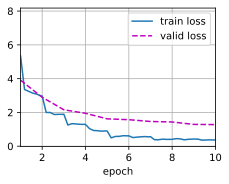

In [11]:
num_epochs, lr, wd = 10, 1e-4, 1e-4
lr_period, lr_decay = 2, 0.9
backbone, head = get_net()
head = train(backbone, head, train_iter, valid_iter, num_epochs, lr, wd,
             lr_period, lr_decay)

## Classifying the Testing Set and Submitting Results on Kaggle


Similar to the final step in that section,
in the end all the labeled data (including the validation set) are used for training the model and classifying the testing set.
We will use the trained custom output network
for classification.

train loss 0.296
101.6 examples/sec


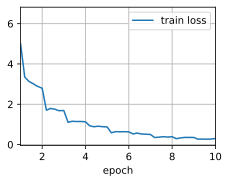

In [12]:
backbone, head = get_net()
head = train(backbone, head, train_valid_iter, None, num_epochs, lr, wd,
             lr_period, lr_decay)
preds = []
for data, label in test_iter:
    logits = head(backbone_features(backbone, data), training=False)
    output = tf.nn.softmax(logits, axis=-1)
    preds.extend(output.numpy())
# Get class names from the train_valid dataset directory
class_names = sorted(os.listdir(
    os.path.join(data_dir, 'train_valid_test', 'train_valid')))
ids = sorted(os.listdir(
    os.path.join(data_dir, 'train_valid_test', 'test', 'unknown')))
with open('submission.csv', 'w') as f:
    f.write('id,' + ','.join(class_names) + '\n')
    for i, output in zip(ids, preds):
        f.write(i.split('.')[0] + ',' + ','.join(
            [str(num) for num in output]) + '\n')

The above code
will generate a `submission.csv` file
to be submitted
to Kaggle in the same way described in that section.


## Summary


* Images in the ImageNet dataset are larger (with varying dimensions) than CIFAR-10 images. We may modify image augmentation operations for tasks on a different dataset.
* To classify a subset of the ImageNet dataset, we can leverage pre-trained models on the full ImageNet dataset to extract features and only train a custom small-scale output network. This will lead to less computational time and memory cost.


## Exercises

1. When using the full Kaggle competition dataset, what results can you achieve when you increase `batch_size` (batch size) and `num_epochs` (number of epochs) while setting some other hyperparameters as `lr = 0.01`, `lr_period = 10`, and `lr_decay = 0.1`?
1. Do you get better results if you use a deeper pretrained model? How do you tune hyperparameters? Can you further improve the results?

[Discussions](https://d2l.discourse.group/t/1481)